# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations :

a)

p = 0.92

Define  X as:

X = 1, if the card is read

X = 0, if the card is not read

For a Bernoulli distribution:

P(X = x) = pˣ(1 − p)¹⁻ˣ

Probability of the card being read

For X = 1:

P(X = 1) = (0.92)¹*(1 − 0.92)¹⁻¹

P(X = 1) = (0.92)*(0.08)⁰

P(X = 1) = 0.92

Therefore,

P(X = 1) = 0.92

Probability of the card not being read

For X = 0:

P(X = 0) = (0.92)⁰*(1 − 0.92)¹⁻⁰

P(X = 0) = (0.92)⁰*(0.08)¹

P(X = 0) = 1(0.08)

Therefore,

P(X = 0) = 0.08

(b) Mean and Variance

For a Bernoulli distribution, the mean is:

Mean = p

Substituting p = 0.92:

Mean = 0.92

Therefore,

Mean = 0.92

Variance

The variance of a Bernoulli distribution is:

Variance = p(1 − p)

Substituting p = 0.92:

Variance = (0.92)(1 − 0.92)

Variance = (0.92)(0.08)

Variance = 0.0736

Therefore,

Variance = 0.0736

Final Answer

P(X = 1) = 0.92

P(X = 0) = 0.08

Mean = 0.92

Variance = 0.0736


PMF:
P(X=0) = 0.0800
P(X=1) = 0.9200

Mean = 0.92
Variance = 0.0736

Checking hand calculations:
Mean matches: True
Variance matches: True


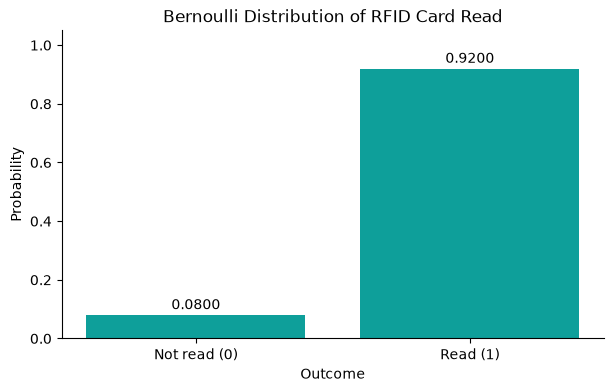

In [3]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
x = np.array([0, 1])
p = 0.92

pmf = stats.bernoulli.pmf(x, p)

print("PMF:")
for value, probability in zip(x, pmf):
    print(f"P(X={value}) = {probability:.4f}")

mean = stats.bernoulli.mean(p)
variance = stats.bernoulli.var(p)

print("\nMean =", mean)
print("Variance =", variance)

hand_mean = 0.92
hand_variance = 0.0736

print("\nChecking hand calculations:")
print("Mean matches:", np.isclose(mean, hand_mean))
print("Variance matches:", np.isclose(variance, hand_variance))

plt.bar(x, pmf, color=DISCRETE_COLOR)

plt.xticks([0, 1], ["Not read (0)", "Read (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution of RFID Card Read")

for i, probability in enumerate(pmf):
    plt.text(i, probability + 0.02, f"{probability:.4f}", ha="center")

plt.ylim(0, 1.05)
plt.show()
# ------------------------------------------------------------

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : 
(a)

Total number of scans = 2000

Number of accepted scans = 1740

For a Bernoulli distribution:

p = Number of successes / Total number of trials

Substituting the values:

p = 1740 / 2000

p = 0.87

Therefore,

p = 0.87

Also,

1 − p = 1 − 0.87

1 − p = 0.13

For a Bernoulli distribution:

P(X = x) = pˣ(1 − p)¹⁻ˣ

Substituting p = 0.87:

P(X = x) = (0.87)*(1 − 0.87)¹⁻ˣ

P(X = x) = (0.87)*(0.13)¹⁻ˣ

where x ∈ {0, 1}

Probability of the fingerprint being accepted

For X = 1:

P(X = 1) = (0.87)¹*(1 − 0.87)¹⁻¹

P(X = 1) = (0.87)¹*(0.13)⁰

P(X = 1) = 0.87*1

P(X = 1) = 0.87

Therefore,

P(X = 1) = 0.87

Probability of the fingerprint not being accepted

For X = 0:

P(X = 0) = (0.87)⁰*(1 − 0.87)¹⁻⁰

P(X = 0) = (0.87)⁰*(0.13)¹

P(X = 0) = 1*(0.13)

P(X = 0) = 0.13

Therefore,

P(X = 0) = 0.13

(b)

For a Bernoulli distribution, the mean is:

Mean = p

Substituting p = 0.87:

Mean = 0.87

Therefore,

Mean = 0.87

Variance

The variance of a Bernoulli distribution is:

Variance = p(1 − p)

Substituting p = 0.87:

Variance = (0.87)*(1 − 0.87)

Variance = (0.87)*(0.13)

Variance = 0.1131

Therefore,

Variance = 0.1131

Maximum possible variance

The variance of a Bernoulli distribution is:

Variance = p(1 − p)

The variance is largest when:

p = 0.5

Substituting p = 0.5:

Variance = (0.5)*(1 − 0.5)

Variance = (0.5)*(0.5)

Variance = 0.25

Therefore,

Maximum variance occurs when p = 0.5

Maximum variance = 0.25

Final Answer

p = 0.87

P(X = x) = (0.87)*(0.13)¹⁻ˣ

P(X = 1) = 0.87

P(X = 0) = 0.13

Mean = 0.87

Variance = 0.1131

Maximum variance occurs at p = 0.5

Maximum variance = 0.25

Theoretical p = 0.8700
Simulated proportion of successes = 0.8675


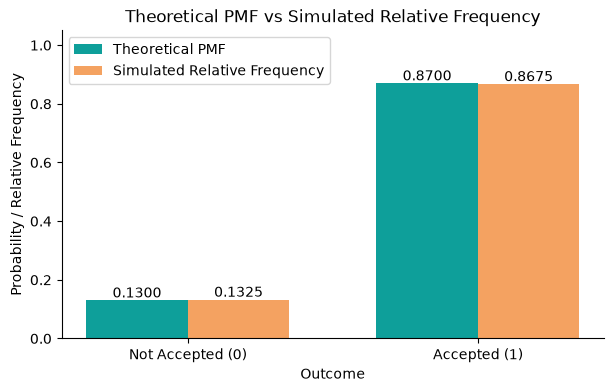

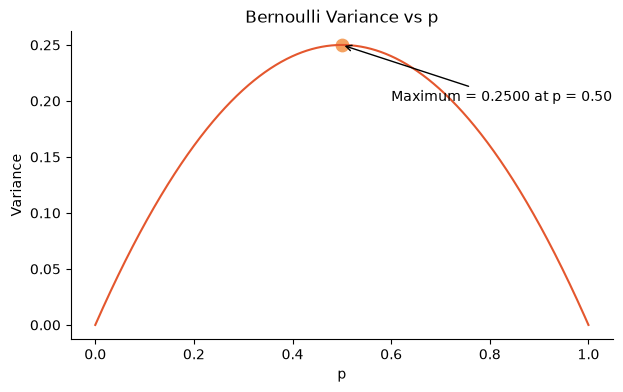

In [6]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
x = np.array([0, 1])

p = 1740 / 2000
n = 2000

pmf = stats.bernoulli.pmf(x, p)

simulated = stats.bernoulli.rvs(p, size=n, random_state=42)

simulated_freq = np.array([
    np.mean(simulated == 0),
    np.mean(simulated == 1)
])

simulated_proportion = np.mean(simulated)

print("Theoretical p =", f"{p:.4f}")
print("Simulated proportion of successes =", f"{simulated_proportion:.4f}")

width = 0.35

plt.bar(x - width/2, pmf, width, color=DISCRETE_COLOR, label="Theoretical PMF")
plt.bar(x + width/2, simulated_freq, width, color=HIGHLIGHT_COLOR, label="Simulated Relative Frequency")

plt.xticks([0, 1], ["Not Accepted (0)", "Accepted (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability / Relative Frequency")
plt.title("Theoretical PMF vs Simulated Relative Frequency")
plt.legend()

for i in range(2):
    plt.text(x[i] - width/2, pmf[i] + 0.01, f"{pmf[i]:.4f}", ha="center")
    plt.text(x[i] + width/2, simulated_freq[i] + 0.01, f"{simulated_freq[i]:.4f}", ha="center")

plt.ylim(0, 1.05)
plt.show()

p_values = np.linspace(0, 1, 1001)
variances = p_values * (1 - p_values)

max_index = np.argmax(variances)
max_p = p_values[max_index]
max_variance = variances[max_index]

plt.plot(p_values, variances, color=CONTINUOUS_COLOR)
plt.scatter(max_p, max_variance, color=HIGHLIGHT_COLOR, s=80)

plt.annotate(
    f"Maximum = {max_variance:.4f} at p = {max_p:.2f}",
    xy=(max_p, max_variance),
    xytext=(0.6, 0.20),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("p")
plt.ylabel("Variance")
plt.title("Bernoulli Variance vs p")

plt.show()
# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : (a)

The number of questions is:

n = 12

Each question has 4 options and exactly 1 correct answer.

Therefore, the probability of answering a question correctly is:

p = 1 / 4

p = 0.25

The probability of answering a question incorrectly is:

1 − p = 1 − 0.25

1 − p = 0.75

Therefore,

n = 12

p = 0.25

Checking the BINS conditions

B — Binary outcomes

Each question has only two possible outcomes:

Correct or Incorrect

Therefore, the binary condition is satisfied.

I — Independent trials

Each question is answered independently by guessing.

Therefore, the independence condition is satisfied.

N — Number of trials is fixed

There are exactly 12 questions.

Therefore, the number of trials is fixed.

S — Same probability of success

Each question has 1 correct option out of 4 options.

Therefore,

p = 1/4 = 0.25

The same probability of success applies to every question.

Therefore, all BINS conditions are satisfied.

Computing P(X = 5)

For a binomial distribution:

P(X = k) = ⁿCₖ pᵏ(1 − p)ⁿ⁻ᵏ

For X = 5:

P(X = 5) = ¹²C₅(0.25)⁵(0.75)¹²⁻⁵

P(X = 5) = ¹²C₅(0.25)⁵(0.75)⁷

Now,

¹²C₅ = 12! / (5!7!)

¹²C₅ = (12 × 11 × 10 × 9 × 8) / (5 × 4 × 3 × 2 × 1)

¹²C₅ = 792

Therefore,

P(X = 5) = 792(0.25)⁵(0.75)⁷

P(X = 5) = 792(0.0009765625)(0.1334838867)

P(X = 5) ≈ 0.1032

Therefore,

P(X = 5) ≈ 0.1032

Typed Calculations : (b)

For a binomial distribution, the mean is:

Mean = np

Substituting n = 12 and p = 0.25:

Mean = (12)(0.25)

Mean = 3

Therefore,

Mean = 3

Variance

The variance of a binomial distribution is:

Variance = np(1 − p)

Substituting n = 12 and p = 0.25:

Variance = (12)(0.25)(1 − 0.25)

Variance = (12)(0.25)(0.75)

Variance = 3(0.75)

Variance = 2.25

Therefore,

Variance = 2.25

Final Answer

n = 12

p = 0.25

1 − p = 0.75

BINS conditions are satisfied.

¹²C₅ = 792

P(X = 5) ≈ 0.1032

Mean = 3

Variance = 2.25

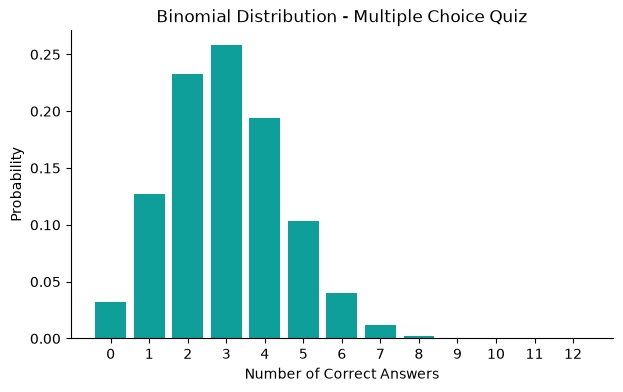

In [4]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n = 12
p = 0.25

k = np.arange(0, 13)

pmf = stats.binom.pmf(k, n, p)

plt.bar(k, pmf, color=DISCRETE_COLOR)

plt.xlabel("Number of Correct Answers")
plt.ylabel("Probability")
plt.title("Binomial Distribution - Multiple Choice Quiz")
plt.xticks(k)

plt.show()









# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : 
(a)

The average number of emails received per hour is:

λ = 3

For a Poisson distribution:

P(X = k) = λᵏe⁻λ / k!

Given:

λ = 3

Also,

e⁻³ ≈ 0.0498

Probability of receiving no emails

For X = 0:

P(X = 0) = (3⁰e⁻³) / 0!

P(X = 0) = (1)(0.0498) / 1

P(X = 0) = 0.0498

Therefore,

P(X = 0) = 0.0498

Probability of receiving exactly 2 emails

For X = 2:

P(X = 2) = (3²e⁻³) / 2!

P(X = 2) = (9)(0.0498) / 2

P(X = 2) = 0.4482 / 2

P(X = 2) = 0.2241

Therefore,

P(X = 2) = 0.2241

(b)

For a Poisson distribution, the mean is:

Mean = λ

Substituting λ = 3:

Mean = 3

Therefore,

Mean = 3

Variance

The variance of a Poisson distribution is:

Variance = λ

Substituting λ = 3:

Variance = 3

Therefore,

Variance = 3

Special property of Poisson distribution

For a Poisson distribution, the mean and variance are equal.

Therefore,

Mean = Variance = λ

Final Answer

λ = 3

P(X = 0) = 0.0498

P(X = 2) = 0.2241

Mean = 3

Variance = 3

Mean = Variance = λ


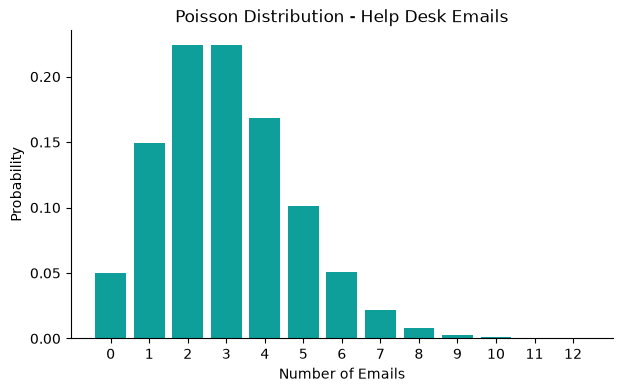

P(X = 0) = 0.0498
P(X = 2) = 0.2240
P(X <= 5) = 0.9161
Smallest value of k for which P(X <= k) >= 0.95: 6


In [3]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam = 3

k = np.arange(0, 13)

pmf = stats.poisson.pmf(k, lam)

plt.bar(k, pmf, color=DISCRETE_COLOR)

plt.xlabel("Number of Emails")
plt.ylabel("Probability")
plt.title("Poisson Distribution - Help Desk Emails")
plt.xticks(k)

plt.show()

p_x0 = stats.poisson.pmf(0, lam)
p_x2 = stats.poisson.pmf(2, lam)
p_x5 = stats.poisson.cdf(5, lam)

k_95 = stats.poisson.ppf(0.95, lam)

print(f"P(X = 0) = {p_x0:.4f}")
print(f"P(X = 2) = {p_x2:.4f}")
print(f"P(X <= 5) = {p_x5:.4f}")
print(f"Smallest value of k for which P(X <= k) >= 0.95: {int(k_95)}")

# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : (a)

The average number of errors per hour is:

λ = 1.5

The night shift is 8 hours.

Therefore, for the whole 8-hour shift:

λ = (1.5)(8)

λ = 12

Therefore,

λ = 12

Probability of a clean shift

A clean shift means zero errors.

Therefore,

X = 0

For a Poisson distribution:

P(X = k) = λᵏe⁻λ / k!

Substituting λ = 12 and X = 0:

P(X = 0) = (12⁰e⁻¹²) / 0!

P(X = 0) = (1)(e⁻¹²) / 1

P(X = 0) = e⁻¹²

P(X = 0) ≈ 0.0000061442

Therefore,

P(X = 0) ≈ 0.000006

Typed Calculations : (b)

For a Poisson distribution, the mean is:

Mean = λ

For the 8-hour window:

λ = 12

Therefore,

Mean = 12

Variance

For a Poisson distribution:

Variance = λ

Substituting λ = 12:

Variance = 12

Therefore,

Variance = 12

Probability of more than 18 errors

The engineer is paged if more than 18 errors occur.

Therefore,

X > 18

The required probability is:

P(X > 18)

Using the complement:

P(X > 18) = 1 − P(X ≤ 18)

For SciPy, the survival function gives this probability directly:

stats.poisson.sf(18, 12)

Therefore,

P(X > 18) = stats.poisson.sf(18, 12)

Final Answer

λ for 8-hour shift = 12

P(X = 0) ≈ 0.000006

Mean = 12

Variance = 12

Probability of being paged = P(X > 18)

SciPy function = stats.poisson.sf(18, 12)

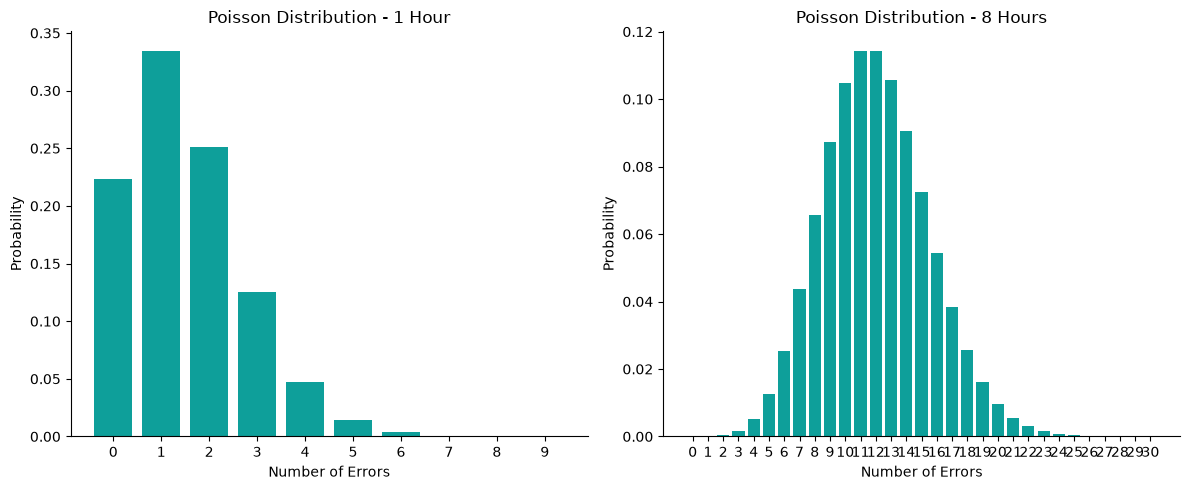

In [5]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam_1 = 1.5
lam_8 = 12

k_1 = np.arange(0, 10)
k_8 = np.arange(0, 31)

pmf_1 = stats.poisson.pmf(k_1, lam_1)
pmf_8 = stats.poisson.pmf(k_8, lam_8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(k_1, pmf_1, color=DISCRETE_COLOR)
axes[0].set_xlabel("Number of Errors")
axes[0].set_ylabel("Probability")
axes[0].set_title("Poisson Distribution - 1 Hour")
axes[0].set_xticks(k_1)

axes[1].bar(k_8, pmf_8, color=DISCRETE_COLOR)
axes[1].set_xlabel("Number of Errors")
axes[1].set_ylabel("Probability")
axes[1].set_title("Poisson Distribution - 8 Hours")
axes[1].set_xticks(k_8)

plt.tight_layout()
plt.show()
# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


yped Calculations : (a)

The mean battery life is:

μ = 18 hours

The standard deviation is:

σ = 1.5 hours

The given battery life is:

X = 15 hours

For a normal distribution, the Z-score is:

Z = (X − μ) / σ

Substituting the values:

Z = (15 − 18) / 1.5

Z = −3 / 1.5

Z = −2

Therefore,

Z = −2

This means that a battery life of 15 hours is 2 standard deviations below the mean.

Typed Calculations : (b)

Using the 68–95–99.7 rule, approximately 95% of the observations lie within 2 standard deviations of the mean.

Therefore,

Interval = μ ± 2σ

Substituting the values:

Interval = 18 ± 2(1.5)

Interval = 18 ± 3

Lower limit = 18 − 3

Lower limit = 15

Upper limit = 18 + 3

Upper limit = 21

Therefore,

15 ≤ X ≤ 21

Approximately 95% of the phones have battery lives between 15 and 21 hours.

Final Answer

Mean = 18 hours

Standard deviation = 1.5 hours

Z-score = −2

15 hours is 2 standard deviations below the mean.

95% interval = 15 to 21 hours

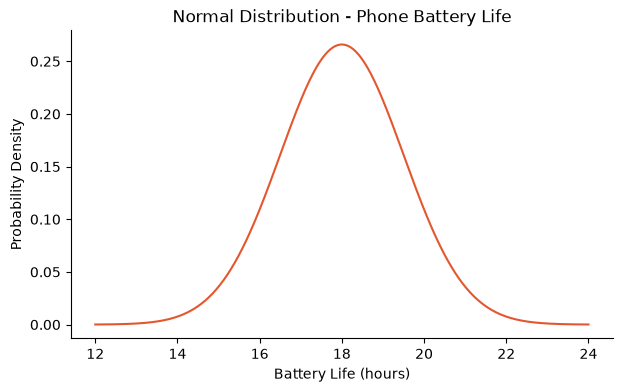

In [6]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 18
sigma = 1.5

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, pdf, color=CONTINUOUS_COLOR)

plt.xlabel("Battery Life (hours)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution - Phone Battery Life")

plt.show()
# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : (a)

The mean fill volume is:

μ = 200 ml

2.5% of cups overflow when the fill volume exceeds 210 ml.

Therefore,

P(X > 210) = 0.025

So,

P(X ≤ 210) = 1 − 0.025

P(X ≤ 210) = 0.975

The standard normal value is:

z₀.₉₇₅ ≈ 1.96

For a normal distribution:

Z = (X − μ) / σ

Substituting the values:

1.96 = (210 − 200) / σ

1.96 = 10 / σ

Therefore,

σ = 10 / 1.96

σ ≈ 5.1020 ml

Therefore,

σ ≈ 5.1020 ml

Typed Calculations : (b)

For the 1st percentile:

P(X ≤ x) = 0.01

The standard normal value for the 1st percentile is:

z₀.₀₁ ≈ −2.3263

Using:

Z = (X − μ) / σ

Substituting the values:

−2.3263 = (X − 200) / 5.1020

Multiplying both sides by 5.1020:

X − 200 = (−2.3263)(5.1020)

X − 200 ≈ −11.8693

Therefore,

X = 200 − 11.8693

X ≈ 188.1307 ml

Therefore,

1st percentile ≈ 188.13 ml

Probability that a customer complains

A customer complains if the cup holds less than 190 ml.

Therefore,

P(X < 190)

Using the normal distribution:

P(X < 190) = stats.norm.cdf(190, μ, σ)

Therefore,

P(X < 190) = stats.norm.cdf(190, 200, 5.1020)

Final Answer

σ ≈ 5.1020 ml

1st percentile ≈ 188.13 ml

Customer complaint probability = P(X < 190)

SciPy function = stats.norm.cdf(190, 200, 5.1020)


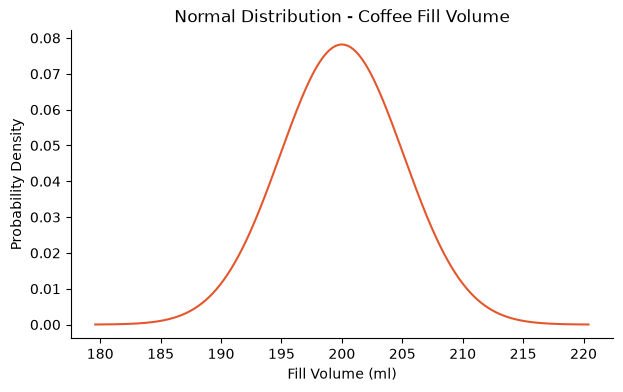

Standard deviation = 5.1021 ml
1st percentile = 188.1307 ml
P(X < 190) = 0.0250


In [7]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 200

z_975 = stats.norm.ppf(0.975)
sigma = (210 - mu) / z_975

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, pdf, color=CONTINUOUS_COLOR)

plt.xlabel("Fill Volume (ml)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution - Coffee Fill Volume")

plt.show()

percentile_1 = stats.norm.ppf(0.01, loc=mu, scale=sigma)

p_complaint = stats.norm.cdf(190, loc=mu, scale=sigma)

print(f"Standard deviation = {sigma:.4f} ml")
print(f"1st percentile = {percentile_1:.4f} ml")
print(f"P(X < 190) = {p_complaint:.4f}")
# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


Typed Calculations : (a)

The waiting time is uniformly distributed between 0 and 15 minutes.

Therefore,

a = 0

b = 15

For a uniform distribution, the mean is:

Mean = (a + b) / 2

Substituting the values:

Mean = (0 + 15) / 2

Mean = 15 / 2

Mean = 7.5

Therefore,

Mean = 7.5 minutes

Variance

For a uniform distribution, the variance is:

Variance = (b − a)² / 12

Substituting the values:

Variance = (15 − 0)² / 12

Variance = 15² / 12

Variance = 225 / 12

Variance = 18.75

Therefore,

Variance = 18.75 minutes²

Final Answer

Mean = 7.5 minutes

Variance = 18.75 minutes²


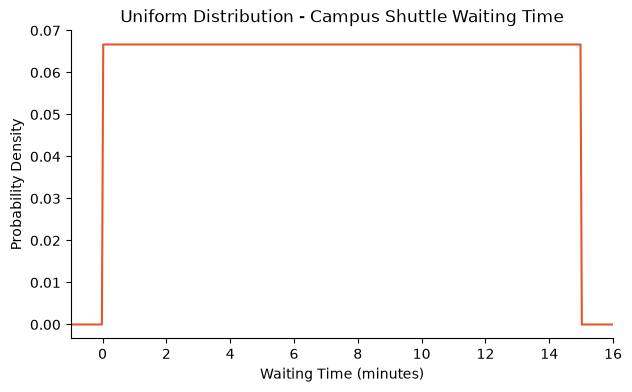

In [8]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
a = 0
b = 15

x = np.linspace(a - 1, b + 1, 400)

pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, pdf, color=CONTINUOUS_COLOR)

plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Probability Density")
plt.title("Uniform Distribution - Campus Shuttle Waiting Time")

plt.xlim(a - 1, b + 1)

plt.show()
# ------------------------------------------------------------

Conclusion

In this assignment, different probability distributions were studied and applied to practical situations. Bernoulli and Binomial distributions were used for discrete events with fixed outcomes, while the Poisson distribution was used to model the number of events occurring over a fixed time period. The Normal distribution was used to study continuous data around a mean, and the Uniform distribution was used for equally likely values within a given interval. The calculations and Python visualizations helped in understanding the probability mass functions, probability density functions, mean, variance, Z-scores, and other important properties of these distributions.